# TV1 Week 4 — Regression Master (FIXED)

**Project:** Retake Behavior & Recovery Analysis  
**Goal:** baseline + 5 regression models + 5-fold GroupKFold + Ridge tuning + leakage check.

Bản này đã sửa 3 lỗi thường gặp:
1. Thiếu `scikit-learn` → có cell kiểm tra/cài package.
2. Sai đường dẫn `model_ready_v1_TV1_fallback.csv` → tự tìm project root và tự tạo `model_ready_v1.csv` từ `data_processed/retake_pairs_v1.csv` nếu cần.
3. `results_df is not defined` → chart có kiểm tra và hướng dẫn chạy các cell model trước.


In [1]:
# CELL 1 — Kiểm tra / cài thư viện
import sys, subprocess, importlib.util

required = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'sklearn': 'scikit-learn'
}
missing = [pip_name for module_name, pip_name in required.items()
           if importlib.util.find_spec(module_name) is None]

if missing:
    print('Thiếu thư viện:', missing)
    print('Đang cài vào đúng Python kernel hiện tại...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
    print('Cài xong. Nếu cell import tiếp theo vẫn báo lỗi, hãy Restart Kernel rồi Run All.')
else:
    print('OK — tất cả thư viện chính đã có.')


OK — tất cả thư viện chính đã có.


## 1. Import và xác định đường dẫn dữ liệu

Notebook **không còn phụ thuộc vào `Path.cwd().parent`**. Nó tự tìm thư mục project có `data_processed/retake_pairs_v1.csv`.


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start] + list(start.parents):
        if (p / 'data_processed' / 'retake_pairs_v1.csv').exists():
            return p
    for child in start.iterdir() if start.exists() else []:
        if child.is_dir() and (child / 'data_processed' / 'retake_pairs_v1.csv').exists():
            return child
    raise FileNotFoundError('Không tìm thấy data_processed/retake_pairs_v1.csv')

PROJECT_ROOT = find_project_root(Path.cwd())
W4_DIR = PROJECT_ROOT / 'w4 - tv1'
SOURCE_DATA = PROJECT_ROOT / 'data_processed' / 'retake_pairs_v1.csv'
MODEL_READY = W4_DIR / 'model_ready_v1.csv'

print('PROJECT_ROOT =', PROJECT_ROOT)
print('SOURCE_DATA  =', SOURCE_DATA)
print('MODEL_READY  =', MODEL_READY)


PROJECT_ROOT = C:\Users\PC\Documents\GitHub\ADY201m_Retake_Recovery
SOURCE_DATA  = C:\Users\PC\Documents\GitHub\ADY201m_Retake_Recovery\data_processed\retake_pairs_v1.csv
MODEL_READY  = C:\Users\PC\Documents\GitHub\ADY201m_Retake_Recovery\w4 - tv1\model_ready_v1.csv


## 2. Tạo / đọc model-ready dataset

Target: `score_delta`.  
Predictors: `initial_failure_total`, `initial_failure_type`, `time_gap`, `prior_attempt_count`, `course_id`.


In [3]:
features = ['initial_failure_total','initial_failure_type','time_gap','prior_attempt_count','course_id']
target = 'score_delta'
required_cols = ['student_id'] + features + [target]

if MODEL_READY.exists():
    df = pd.read_csv(MODEL_READY)
    print('Using existing model-ready file.')
else:
    source_df = pd.read_csv(SOURCE_DATA)
    missing_cols = [c for c in required_cols if c not in source_df.columns]
    if missing_cols:
        raise ValueError(f'Missing required columns: {missing_cols}')
    df = source_df[required_cols].copy()
    df = df.dropna(subset=[target, 'student_id']).reset_index(drop=True)
    df.to_csv(MODEL_READY, index=False)
    print('Created:', MODEL_READY)

# Đảm bảo target không bị missing
before = len(df)
df = df.dropna(subset=[target, 'student_id']).reset_index(drop=True)
print('Rows:', len(df), '| Removed:', before-len(df))
print('Unique students:', df['student_id'].nunique())
df.head()


Using existing model-ready file.
Rows: 10786 | Removed: 0
Unique students: 5788


,student_id,initial_failure_total,initial_failure_type,time_gap,prior_attempt_count,course_id,score_delta
0,0301AFJHII,4.9,FAIL_ACADEMIC,1.0,0,PRJ301,-4.9
1,0305ADJFFI,4.1,FAIL_ACADEMIC,1.0,0,CSD201,3.3
2,0305ADJFFI,4.5,FAIL_ACADEMIC,2.0,0,PRO192,1.4
3,0305ADJFFI,2.8,FAIL_ATTENDANCE,1.0,0,OSG202,1.7
4,0305ADJFFI,1.0,FAIL_ATTENDANCE,1.0,0,PRF192,4.4


## 3. Data leakage check

Không dùng `next_attempt_total`, `next_status_group`, `pass_next_attempt` hoặc `score_delta` làm predictor.


In [4]:
forbidden = {'next_attempt_total','next_status_group','pass_next_attempt','score_delta'}
leaked = set(features) & forbidden
assert not leaked, f'DATA LEAKAGE: {leaked}'
print('Leakage feature check: PASSED')
print(df[['student_id'] + features + [target]].isna().sum())


Leakage feature check: PASSED
student_id               0
initial_failure_total    0
initial_failure_type     0
time_gap                 0
prior_attempt_count      0
course_id                0
score_delta              0
dtype: int64


## 4. Group-aware Train/Test Split

Dùng `student_id` làm group để cùng một sinh viên không xuất hiện ở cả train và test.


In [5]:
X = df[features].copy()
y = df[target].copy()
groups = df['student_id'].copy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

print('Train rows:', len(train_idx))
print('Test rows :', len(test_idx))
print('Train students:', groups_train.nunique())
print('Test students :', groups_test.nunique())
print('Student overlap:', len(set(groups_train) & set(groups_test)))


Train rows: 8557
Test rows : 2229
Train students: 4630
Test students : 1158
Student overlap: 0


## 5. Preprocessing chung

- Numeric: median imputation + StandardScaler.
- Categorical: most-frequent imputation + OneHotEncoder.


In [6]:
numeric_features = ['initial_failure_total','time_gap','prior_attempt_count']
categorical_features = ['initial_failure_type','course_id']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

def make_pipeline(model):
    return Pipeline([('preprocessor', preprocessor), ('model', model)])


## 6. Baseline + 5 regression models


In [7]:
models = {
    'Dummy Baseline': make_pipeline(DummyRegressor(strategy='mean')),
    'Linear Regression': make_pipeline(LinearRegression()),
    'Ridge Regression': make_pipeline(Ridge(alpha=1.0)),
    'Lasso Regression': make_pipeline(Lasso(alpha=0.01, max_iter=10000)),
    'Random Forest': make_pipeline(RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)),
    'Gradient Boosting': make_pipeline(GradientBoostingRegressor(n_estimators=150, learning_rate=0.05, max_depth=3, random_state=42))
}
list(models.keys())


['Dummy Baseline',
 'Linear Regression',
 'Ridge Regression',
 'Lasso Regression',
 'Random Forest',
 'Gradient Boosting']

## 7. 5-fold Group Cross-Validation + Test Metrics

Cell này **tạo `results_df`**. Vì vậy phải chạy cell này trước khi vẽ Model Comparison Chart.


In [8]:
gkf = GroupKFold(n_splits=5)
results = []
fitted_models = {}

for name, model in models.items():
    print('Training:', name)
    cv_rmse = -cross_val_score(
        model, X_train, y_train,
        cv=gkf, groups=groups_train,
        scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append({
        'Model': name,
        'CV_RMSE_Mean': cv_rmse.mean(),
        'CV_RMSE_SD': cv_rmse.std(),
        'Test_MAE': mean_absolute_error(y_test, pred),
        'Test_RMSE': mean_squared_error(y_test, pred) ** 0.5,
        'Test_R2': r2_score(y_test, pred)
    })
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values('Test_RMSE').reset_index(drop=True)
results_df.round(4)


Training: Dummy Baseline
Training: Linear Regression
Training: Ridge Regression
Training: Lasso Regression
Training: Random Forest
Training: Gradient Boosting


,Model,CV_RMSE_Mean,CV_RMSE_SD,Test_MAE,Test_RMSE,Test_R2
0,Gradient Boosting,2.4506,0.0325,2.0555,2.4895,0.1585
1,Ridge Regression,2.4762,0.0283,2.0791,2.4957,0.1543
2,Linear Regression,2.4761,0.0286,2.0785,2.4957,0.1543
3,Lasso Regression,2.4817,0.0269,2.0885,2.5038,0.1488
4,Random Forest,2.4842,0.0283,2.0689,2.5203,0.1375
5,Dummy Baseline,2.7028,0.0523,2.1844,2.7147,-0.0006


## 8. Ridge Tuning


In [10]:
ridge_pipe = make_pipeline(Ridge())
param_grid = {'model__alpha':[0.01,0.1,1,10,100]}

grid = GridSearchCV(
    ridge_pipe, param_grid,
    cv=gkf, scoring='neg_root_mean_squared_error', n_jobs=-1
)
grid.fit(X_train, y_train, groups=groups_train)

print('Best alpha:', grid.best_params_['model__alpha'])
print('Best CV RMSE:', -grid.best_score_)


Best alpha: 0.1
Best CV RMSE: 2.4761319048419814


## 9. Model Comparison Chart

Nếu chạy riêng cell này trước cell model, thay vì lỗi `NameError`, notebook sẽ báo rõ cần chạy cell nào trước.


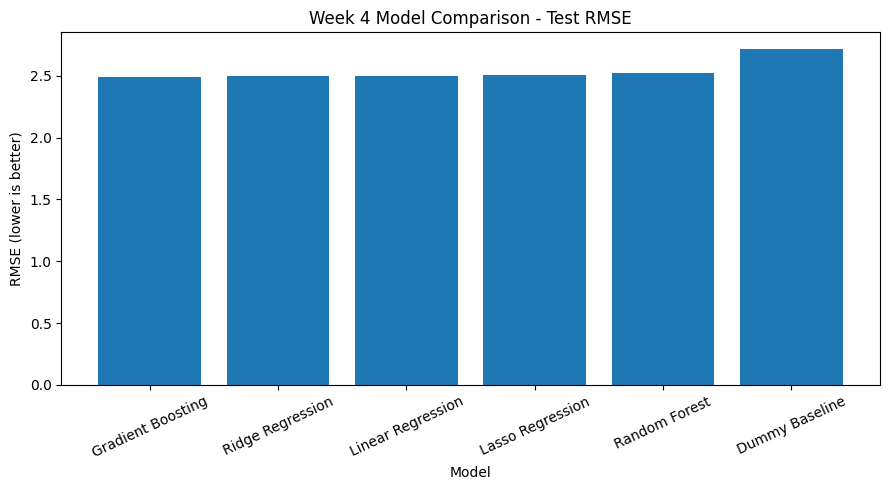

In [11]:
if 'results_df' not in globals():
    raise RuntimeError("Chưa có results_df. Hãy chạy cell '5-fold Group Cross-Validation + Test Metrics' trước, hoặc chọn Restart Kernel → Run All.")

plot_df = results_df.sort_values('Test_RMSE')
plt.figure(figsize=(9,5))
plt.bar(plot_df['Model'], plot_df['Test_RMSE'])
plt.title('Week 4 Model Comparison - Test RMSE')
plt.ylabel('RMSE (lower is better)')
plt.xlabel('Model')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


## 10. Cách đọc kết quả khi thuyết trình

- MAE/RMSE: **thấp hơn tốt hơn**.
- R²: **cao hơn tốt hơn**.
- Baseline là mốc tham chiếu.
- Không diễn giải feature/model như quan hệ nhân quả.
- `prior_attempt_count` gần như không biến thiên trong first-failure cohort; nêu đây là limitation.
